# 04 — NBN footprint

**What this notebook does.** Reduces the two NBN technology-footprint shapefiles
(fixed-line, fixed-wireless) to **one polygon per technology** covering the NT, so a later
step can ask "does this village's point sit inside an NBN fixed-line / fixed-wireless
polygon?" — i.e. is fixed broadband even an option there, or is it Sky Muster satellite.

**This is a footprint, not a guarantee of service.** A point inside the polygon means NBN
lists that ground as within a fixed technology's serving area; it is not a speed or an
install date.

**What it reads** (external / raw only):

| dataframe | file | notes |
|---|---|---|
| `nbn_fixedline_gdf` | `external/nbn/fixedline/nbn_coverage_fixedline.shp` | attribute col `polygon_id`; EPSG:4283; read within the NT bbox |
| `nbn_wireless_gdf` | `external/nbn/wireless/nbn_coverage_wireless.shp` | attribute col `Polygon_id` (different case); EPSG:4283; NT bbox |
| `bushtel_communities_gdf` | `raw/bushtel/Com_BushTel_Profile_CMC_2024.json` | 792 village points — **for the validation map / count only**, not written |

**What it writes** (`data/new_processed/`):

| file | one row is | key | rows |
|---|---|---|---|
| `nbn_footprint.geojson` | one technology's dissolved NT footprint | `technology` | 2 (`fixed_line`, `fixed_wireless`) |

**From 00b:** the only real attribute is a polygon id (and the two files spell it with
different capitalisation), so `technology` is set from *which file* the polygon came from.
Fixed-wireless polygons sit almost entirely around Darwin / Tiwi; fixed-line is ~35 town
footprints. Most remote villages will be outside both — expected, not a bug.

In [1]:
# Every import for the whole notebook lives in this cell.
%matplotlib inline
import os
from pathlib import Path

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

In [2]:
# Every file the notebook needs is read here, one line each.

NBN_FIXEDLINE_SHP = "data/external/nbn/fixedline/nbn_coverage_fixedline.shp"
NBN_WIRELESS_SHP  = "data/external/nbn/wireless/nbn_coverage_wireless.shp"
BUSHTEL_JSON      = "data/raw/bushtel/Com_BushTel_Profile_CMC_2024.json"

# rough NT bounding box (lon_min, lat_min, lon_max, lat_max) — the shapefiles are national
NT_BBOX  = (128.9, -26.3, 138.1, -10.8)
CRS_NBN  = "EPSG:4283"   # GDA94 — what the .prj says (some copies have no .prj at all)
CRS_OUT  = "EPSG:4326"   # plain lat/long, to match every point file and the other outputs
CRS_AREA = "EPSG:3577"   # Australian Albers, equal-area — for honest km² numbers only

nbn_fixedline_gdf       = gpd.read_file(NBN_FIXEDLINE_SHP, bbox=NT_BBOX)
nbn_wireless_gdf        = gpd.read_file(NBN_WIRELESS_SHP,  bbox=NT_BBOX)
bushtel_communities_gdf = gpd.read_file(BUSHTEL_JSON)

OUT_DIR = Path("data/new_processed"); OUT_DIR.mkdir(parents=True, exist_ok=True)
EDA_PLOT_DIR = Path("docs/eda"); EDA_PLOT_DIR.mkdir(parents=True, exist_ok=True)
eda_figures = {}

print(f"nbn_fixedline_gdf       : {len(nbn_fixedline_gdf)} polygons in the NT bbox")
print(f"nbn_wireless_gdf        : {len(nbn_wireless_gdf)} polygons in the NT bbox")
print(f"bushtel_communities_gdf : {len(bushtel_communities_gdf)} village points")

nbn_fixedline_gdf       : 35 polygons in the NT bbox
nbn_wireless_gdf        : 348 polygons in the NT bbox
bushtel_communities_gdf : 792 village points


## 1. Inspect the two shapefiles as read

In [3]:
for label, gdf in [("fixed-line", nbn_fixedline_gdf), ("fixed-wireless", nbn_wireless_gdf)]:
    print(f"{label:14s}: cols={list(gdf.columns)}  CRS={gdf.crs}  "
          f"geom={gdf.geom_type.value_counts().to_dict()}")
    print(f"{'':14s}  bounds={[round(x, 2) for x in gdf.total_bounds]}  "
          f"null/empty geom={int(gdf.geometry.isna().sum() + gdf.geometry.is_empty.sum())}")
print("\n-> attribute column differs in case (`polygon_id` vs `Polygon_id`) and carries no "
      "technology/speed info, so we keep only the geometry and label by source file.")

fixed-line    : cols=['polygon_id', 'geometry']  CRS=EPSG:4283  geom={'Polygon': 33, 'MultiPolygon': 2}
                bounds=[np.float64(130.81), np.float64(-23.82), np.float64(136.9), np.float64(-12.17)]  null/empty geom=0
fixed-wireless: cols=['Polygon_id', 'geometry']  CRS=EPSG:4283  geom={'Polygon': 346, 'MultiPolygon': 2}
                bounds=[np.float64(130.63), np.float64(-12.9), np.float64(131.36), np.float64(-12.31)]  null/empty geom=0

-> attribute column differs in case (`polygon_id` vs `Polygon_id`) and carries no technology/speed info, so we keep only the geometry and label by source file.


## 2. One polygon per technology

For each file: set the CRS if the `.prj` was missing, reproject to plain lat/long, throw
away every attribute except the geometry, tag `technology` from the source file, and
`dissolve` all the little polygons into one shape.

In [4]:
def dissolve_footprint(gdf, technology):
    g = gdf.copy()
    if g.crs is None:
        g = g.set_crs(CRS_NBN)                 # the .prj says GDA94
    g = g.to_crs(CRS_OUT)[["geometry"]]
    g = g[~(g.geometry.isna() | g.geometry.is_empty)]
    g["technology"] = technology
    return g.dissolve(by="technology").reset_index()

fixed_line_footprint_gdf     = dissolve_footprint(nbn_fixedline_gdf, "fixed_line")
fixed_wireless_footprint_gdf = dissolve_footprint(nbn_wireless_gdf, "fixed_wireless")

nbn_footprint_gdf = gpd.GeoDataFrame(
    pd.concat([fixed_line_footprint_gdf, fixed_wireless_footprint_gdf], ignore_index=True),
    geometry="geometry", crs=CRS_OUT)
nbn_footprint_gdf

,technology,geometry
0,fixed_line,"MULTIPOLYGON (((130.8413 -12.46742, 130.8411 -..."
1,fixed_wireless,"MULTIPOLYGON (((130.89923 -12.89625, 130.8997 ..."


### Validate: polygon count before / after the dissolve, and footprint area

In [5]:
area_km2 = nbn_footprint_gdf.to_crs(CRS_AREA).area / 1e6
for tech, n_before in [("fixed_line", len(nbn_fixedline_gdf)), ("fixed_wireless", len(nbn_wireless_gdf))]:
    a = float(area_km2[nbn_footprint_gdf["technology"] == tech].iloc[0])
    print(f"{tech:14s}: {n_before:>4} polygons -> 1   |   footprint area {a:,.0f} km²  "
          f"({a / 1_349_129 * 100:.2f}% of the NT's ~1.35M km²)")

assert len(nbn_footprint_gdf) == 2, "expected exactly 2 rows (one per technology)"
assert set(nbn_footprint_gdf["technology"]) == {"fixed_line", "fixed_wireless"}
assert nbn_footprint_gdf.geometry.notna().all() and (~nbn_footprint_gdf.geometry.is_empty).all()
assert nbn_footprint_gdf.crs.to_epsg() == 4326

fixed_line    :   35 polygons -> 1   |   footprint area 227 km²  (0.02% of the NT's ~1.35M km²)
fixed_wireless:  348 polygons -> 1   |   footprint area 1,279 km²  (0.09% of the NT's ~1.35M km²)


## 3. Validate against the villages — how many sit inside each footprint?

`within` join of the 792 village points against each dissolved polygon. This is the number
that matters for nb 06: a low count is the expected story (remote = satellite), not an error.

In [6]:
villages_4326 = bushtel_communities_gdf.to_crs(CRS_OUT)[["community_id", "community_name", "geometry"]]

inside = {}
for tech in ("fixed_line", "fixed_wireless"):
    poly = nbn_footprint_gdf.loc[nbn_footprint_gdf["technology"] == tech, "geometry"].iloc[0]
    inside[tech] = villages_4326[villages_4326.within(poly)]
    print(f"villages inside {tech:14s}: {len(inside[tech]):>3} / {len(villages_4326)}")

either = villages_4326[villages_4326.within(nbn_footprint_gdf.union_all())]
print(f"villages inside EITHER footprint : {len(either)} / {len(villages_4326)}")
print("\nthe villages inside fixed-line:")
print("   " + ", ".join(sorted(inside["fixed_line"]["community_name"])[:40]))

villages inside fixed_line    :  30 / 792
villages inside fixed_wireless:   1 / 792


villages inside EITHER footprint : 31 / 792

the villages inside fixed-line:
   AKNGWERTNARRE, ALICE SPRINGS, ANTHELK EWLPAYE, APER ALWERRKNGE, BAGOT, DARWIN, HOPPYS CAMP, INARLENGE, IRKLANCHA ATWACHA, JABIRU, KARGARU, KATHERINE, KULALUK, KUNOTH, MANABURDURMA, MARLA MARLA, MIALI BRUMBY, MINMARAMA PARK, MPWETYERRE, MUNJI-MARLA, NGALPA NGALPA, NHULUNBUY, PALMERSTON, PALMERSTON INDIGENOUS VILLAGE, RAILWAY DAM, TENNANT CREEK, TINKARLI, VILLAGE CAMP, WUPPA, YIRRKALA


## 4. Validation map — both footprints over the NT with villages on top

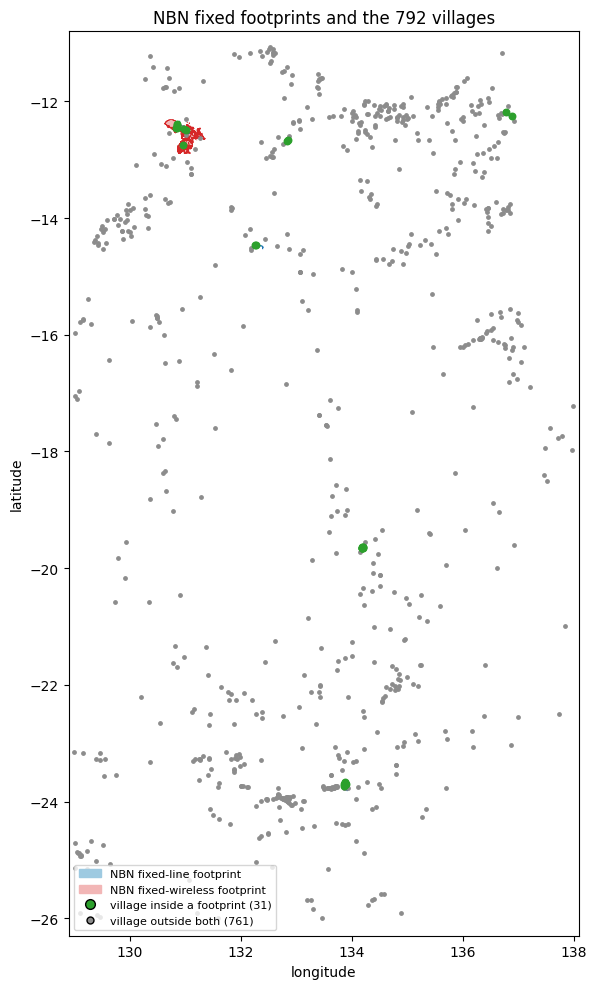

In [7]:
villages_plot = bushtel_communities_gdf.to_crs(CRS_OUT).copy()
in_either = villages_plot.within(nbn_footprint_gdf.union_all())

fig, ax = plt.subplots(figsize=(8.5, 10))
nbn_footprint_gdf[nbn_footprint_gdf["technology"] == "fixed_wireless"].plot(
    ax=ax, color="#f2b6b6", edgecolor="#d62728", linewidth=0.5)
nbn_footprint_gdf[nbn_footprint_gdf["technology"] == "fixed_line"].plot(
    ax=ax, color="#9ecae1", edgecolor="#1f77b4", linewidth=0.5)
villages_plot[~in_either].plot(ax=ax, color="0.55", markersize=6)
villages_plot[in_either].plot(ax=ax, color="#2ca02c", markersize=22)
ax.set_xlim(NT_BBOX[0], NT_BBOX[2]); ax.set_ylim(NT_BBOX[1], NT_BBOX[3])
ax.legend(handles=[
    mpatches.Patch(color="#9ecae1", label="NBN fixed-line footprint"),
    mpatches.Patch(color="#f2b6b6", label="NBN fixed-wireless footprint"),
    Line2D([], [], marker="o", color="none", markerfacecolor="#2ca02c", markersize=7,
           label=f"village inside a footprint ({int(in_either.sum())})"),
    Line2D([], [], marker="o", color="none", markerfacecolor="0.55", markersize=5,
           label=f"village outside both ({int((~in_either).sum())})"),
], fontsize=8, loc="lower left")
ax.set_title("NBN fixed footprints and the 792 villages")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
fig.tight_layout()
eda_figures["04_nbn_footprint_villages"] = fig

In [8]:
# Second-to-last cell: summary print.
print("04_nbn_footprint — summary")
print("-" * 60)
print(f"fixed_line     : {len(nbn_fixedline_gdf):>4} polygons -> 1  "
      f"({float((nbn_footprint_gdf.to_crs(CRS_AREA).area / 1e6)[nbn_footprint_gdf['technology']=='fixed_line'].iloc[0]):,.0f} km²)")
print(f"fixed_wireless : {len(nbn_wireless_gdf):>4} polygons -> 1  "
      f"({float((nbn_footprint_gdf.to_crs(CRS_AREA).area / 1e6)[nbn_footprint_gdf['technology']=='fixed_wireless'].iloc[0]):,.0f} km²)")
print(f"villages inside fixed_line {len(inside['fixed_line'])}, fixed_wireless {len(inside['fixed_wireless'])}, "
      f"either {len(either)} of {len(villages_4326)}")
print("rows out : 2 (nbn_footprint.geojson, key = technology)")
print("asserts  : 2 rows, both technologies present, non-null geometry, CRS EPSG:4326")

04_nbn_footprint — summary
------------------------------------------------------------
fixed_line     :   35 polygons -> 1  (227 km²)
fixed_wireless :  348 polygons -> 1  (1,279 km²)
villages inside fixed_line 30, fixed_wireless 1, either 31 of 792
rows out : 2 (nbn_footprint.geojson, key = technology)
asserts  : 2 rows, both technologies present, non-null geometry, CRS EPSG:4326


In [9]:
# Last cell: every file write.
geojson_path = OUT_DIR / "nbn_footprint.geojson"
nbn_footprint_gdf.to_file(geojson_path, driver="GeoJSON")

for name, fig in eda_figures.items():
    fig.savefig(EDA_PLOT_DIR / f"{name}.png", dpi=120, bbox_inches="tight")

print("wrote:")
print(" ", geojson_path, f"({len(nbn_footprint_gdf)} features)")
for name in eda_figures:
    print("  docs/eda/" + name + ".png")

wrote:
  data\new_processed\nbn_footprint.geojson (2 features)
  docs/eda/04_nbn_footprint_villages.png
